In [1]:
using Random, Distributions
using JuMP
using SCS
using LinearAlgebra
using Plots
using LaTeXStrings

# generate synthetic data about a known line
function sample_data(n)
    x = 2 .* rand(n) .- 1
    
    m_true = 2.0
    b_true = -1.0
    
    sigma = 1.0
    y = m_true .* x .+ b_true .+ sigma .* randn(n)
    
    return x, y, m_true, b_true
end

# store the sample data
x, y, m_true, b_true = sample_data(100)

# W2 Wasserstein SOCP (Euclidean transport cost)
function solve_W2(x, y, epsilon)
    n = length(x)

    model = Model(SCS.Optimizer)
    set_silent(model)

    # define variables
    @variable(model, m)
    @variable(model, b)
    @variable(model, s >= 0)
    @variable(model, t[1:n] >= 0)

    # LAD loss
    @constraint(model, [i=1:n], y[i] - (m*x[i] + b) <= t[i])
    @constraint(model, [i=1:n], -(y[i] - (m*x[i] + b)) <= t[i])

    # SOC constraint
    @constraint(model, [s; m; b; 1] in SecondOrderCone())

    # objective
    @objective(model, Min, sum(t)/n + epsilon * s)

    optimize!(model)

    return value(m), value(b) # return slope and intercept
end


# calculate the mean absolute error
function mae(x, y, m, b)
    mean(abs.(y .- (m .* x .+ b)))
end

mae (generic function with 1 method)

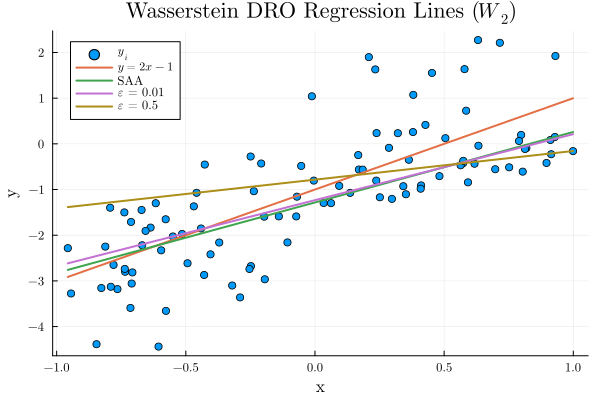

In [2]:
# test some epsilons
ϵ1 = 0.0 # reduces to sample average approximation
ϵ2 = 0.05
ϵ3 = 0.6

# return coefficients from solving dro problem
m1, b1 = solve_W2(x, y, ϵ1)
m2, b2 = solve_W2(x, y, ϵ2)
m3, b3 = solve_W2(x, y, ϵ3)

# plot results
x_line = range(minimum(x), maximum(x), length=200)

p = plot( x, y, seriestype=:scatter, label=L"y_i",
    title=L"Wasserstein DRO Regression Lines ($W_2$)", xlabel="x", ylabel="y",
    fontfamily="Computer Modern"
)

plot!(p, x_line, m_true .* x_line .+ b_true, lw=2, label=L"y=2x-1")
plot!(p, x_line, m1 .* x_line .+ b1, lw=2, label="SAA")
plot!(p, x_line, m2 .* x_line .+ b2, lw=2, label=L"$\epsilon$ = 0.01")
plot!(p, x_line, m3 .* x_line .+ b3, lw=2, label=L"$\epsilon$ = 0.5")

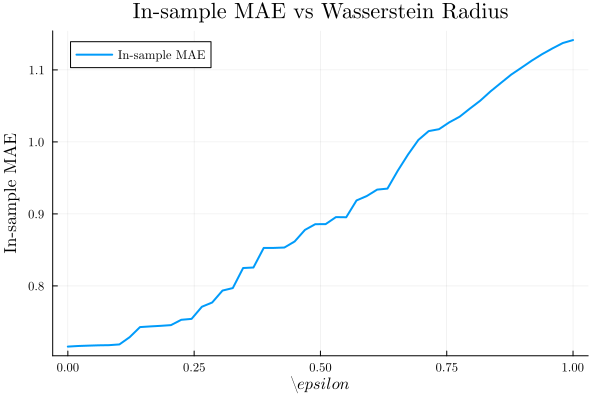

In [4]:
epsilons = range(0, 1, length=50) # generate epsilons
mae_vals = Float64[] # container for error values

# test each epsilon
for epsilon in epsilons
    m, b = solve_W2(x,y,epsilon) # solve the problem for new radius
    error = mean(abs.(y .- (m .* x .+ b))) # calculate the MAE 
    push!(mae_vals, error)
end

# plot results
p3 = plot(epsilons, mae_vals, xlabel=L"\$epsilon$", ylabel="In-sample MAE",
    title="In-sample MAE vs Wasserstein Radius", label="In-sample MAE", lw=2,
    fontfamily="Computer Modern"
)

display(p3)

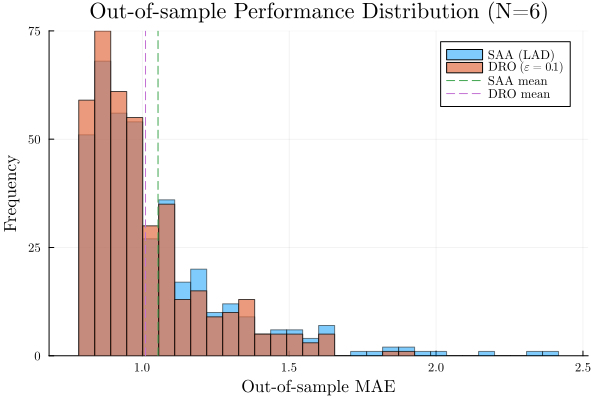

SAA mean MAE: 1.053776231432905 std: 0.2632304384585631
DRO mean MAE: 1.0111850820772923 std: 0.19908281572134692
SAA worst 10% mean: 1.6678714494448104
DRO worst 10% mean: 1.4686033148767652


In [5]:
# compare DRO to SAA performance when training data is limited

trials = 400
test_n = 10000
epsilon = 0.1
train_n = 6

# collect errors
mae_dro = Float64[]
mae_saa = Float64[]
    
# loop through each trial
for _ in 1:trials

    # train test split
    x_train, y_train, _, _ = sample_data(train_n)
    x_test, y_test, _, _   = sample_data(test_n)
    
    # get slope and intercept for each model
    m_saa, b_saa = solve_W2(x_train, y_train, 0.0)
    m_dro, b_dro = solve_W2(x_train, y_train, epsilon)
    
    # calculate and record errors
    push!(mae_saa, mae(x_test, y_test, m_saa, b_saa))
    push!(mae_dro, mae(x_test, y_test, m_dro, b_dro))
end

# set up histogram

# define edges
edges = range(min(minimum(mae_saa), minimum(mae_dro)), max(maximum(mae_saa), 
    maximum(mae_dro)), length=31)

p5 = histogram(mae_saa, bins=edges, label="SAA (LAD)", 
    xlabel="Out-of-sample MAE", ylabel="Frequency",
    title="Out-of-sample Performance Distribution (N=6)",fontfamily="Computer Modern", alpha=0.5)

# DRO histogram
histogram!(p5, mae_dro, bins=edges, label=L"DRO $(\epsilon=0.1)$", alpha=0.7)

# set up vlines for the mean MAEs across all tests
vline!(p5, [mean(mae_saa)], label="SAA mean", linestyle=:dash)
vline!(p5, [mean(mae_dro)], label="DRO mean", linestyle=:dash)

# print moment figures
println("SAA mean MAE: ", mean(mae_saa), " std: ", std(mae_saa))
println("DRO mean MAE: ", mean(mae_dro), " std: ", std(mae_dro))

# last 10%
println("SAA worst 10% mean: ", mean(sort(mae_saa)[360:end]))
println("DRO worst 10% mean: ", mean(sort(mae_dro)[360:end]))

display(p5)


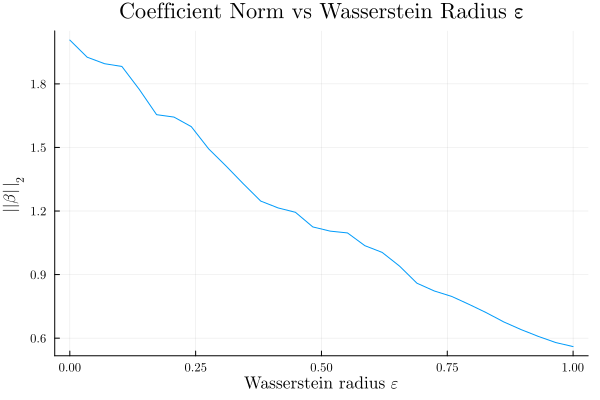

In [6]:
# epsilons to test
epsilon_vals = range(0.0, 1.0, length=30)

# container for norms
norms = Float64[]

# loop over each epsilon
for epsilon in epsilon_vals
    m_hat, b_hat = solve_W2(x,y,epsilon) # return regression coefficients
    push!(norms, norm([m_hat, b_hat]))
end

# plot results
plot(epsilon_vals, norms, xlabel=L"Wasserstein radius $\epsilon$",
     ylabel=L"$||\beta||_2$", title="Coefficient Norm vs Wasserstein Radius ε",
     legend=false, fontfamily="Computer Modern")